# **USANDO LSTM E BEAM SEARCH PARA AUTOCOMPLETAR TEXTOS**

## **REALIZANDO O ENCODING DO TEXTO**

Para trabalharmos com texto como entrada da *RNN*, primeiro é necessário codificá-lo da maneira adequada. Para isso, utilizamos a técnica **one-hot encoding**, a mesma usada para as categorias nos problemas de classificação de imagem. Usaremos essa técnica, pois, nesse primeiro momento trabalharemos com o texto como uma sequência de caracteres, não como uma sequência de palavras. Logo, o *one-hot encoding* funciona bem para caracteres, haja vista que temos somente algumas dezenas de caracteres. Pensando nesse caminho, o *one-hot encoding* de palavras é menos eficiente, pois resultaria em vetores muito mais largos, porque a largura do vetor de entrada é a mesma que o número total de símbolos a serem codificados, e uma língua típica contém dezenas ou centenas de milhares de palavras.

Para tornar mais concreto e simples, suponha que o texto consista apenas em caracteres minúsculos e sem símbolos especiais (,.!@). A partir disso, podemos codificar um caractere como um vetor *one-hot* de largura 26, porque existem 26 caracteres minúsculos (trabalhando com a língua inglesa). Com isso, podemos definir uma *RNN* que recebe um vetor de 26 elementos como a entrada **x** e termina com uma camada *softmax* conectada a 26 saídas (cada caractere minúsculo do alfabeto).

Agora podemos apresentar uma sequência de texto à rede, alimentando-a com um único caractere codificado em one-hot para cada passo de tempo, e a saída *softmax* pode ser interpretada como o que a rede prevê como sendo o próximo caractere. A saída de maior valor representa o caractere que a rede considera mais provável de ser o próximo. A saída com o segundo maior valor corresponde ao segundo caractere mais provável, e assim por diante.

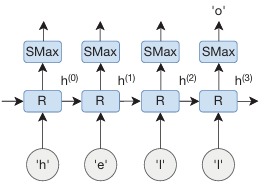 *RNN projetada acima em "funcionamento"*

A imagem acima ilustra a rede recorrente que pensamos para o caso. A cada passo de tempo um caractere é apresentado como *input* para a rede e no último passo de tempo ela prevê como próxima letra a letra **"o"**. Obviamente, a rede preverá algo durante os primeiros passos de tempo também, mas ignoramos as saídas durante esses passos porque sabemos que ainda não apresentamos a sequência de entrada inteira.

## **PREVENDO MÚLTIPLOS VALORES**

Nos materiais anteriores, o foco era prever sempre o próximo valor em uma sequência temporal. No entanto, muitas vezes, é útil ser capaz de prever sequências de saída mais longas do que apenas um único valor.

A maneira mais simples é criar múltiplos modelos, onde cada modelo adicional prevê um passo de tempo mais adiante. Para ilustrar isso, lembre do modelo de previsão de vendas de livros do material sobre *RNN*. Apresentamos ao modelo os dados de *input* e o valor de saída desejado *Y(t+1)*. Se tivéssemos usado os mesmos dados de entrada, mas em vez disso os apresentássemos com o valor de saída desejado para um passo de tempo posterior *Y(t+2)*, teríamos o modelo que prevê dois passos no futuro. Poderíamos então criar ainda outro modelo que treinamos com *Y(t+3)*, e assim por diante.  Essa abordagem é simples de implementar, mas não tão flexível, e também não há compartilhamento ou reutilização entre os modelos.

Outra opção é criar um modelo que prevê *m* passos de tempo de uma só vez. O modelo seria definido para ter *m* saídas. Cada exemplo de treinamento consistiria nos dados de *input* e a saída desejada agora é uma sequência de *m* elementos. Com essa abordagem, obtemos o benefício potencial de reutilizar parâmetros para prever múltiplos passos de tempo, mas precisamos decidir previamente quantos passos no futuro queremos prever, e se quisermos prever sequências extremamente longas, acabamos com um grande número de neurônios de saída.

Com essas duas abordagens, precisamos decidir previamente, no momento do treinamento, quantos passos de tempo queremos prever. No entanto, assim como queremos ser capazes de processar sequências de entrada de comprimentos variáveis, gostaríamos de escolher dinamicamente o comprimento da sequência de saída.

Uma maneira inteligente de fazer isso para o caso em que o modelo prevê um valor futuro de uma variável com base apenas nos valores históricos dela mesma é pegar o valor de saída previsto para um passo de tempo e jogá-lo como entrada para o modelo no próximo passo de tempo. Quando um modelo de *Deep Learning* usa saída de um passo de tempo como entrada para o próximo passo, ele é chamado de **modelo autorregressivo**.

Pensando no exemplo de autocompletar texto, uma boa ideia é alimentá-la, primeiramente, com o início da frase que queremos autocompletar, a partir disso ela irá prever um caractere. Esse caractere previsto será usado para realimentar a rede como entrada de maneira autorregressiva.

No entanto, não estamos pegando a saída exatamente como ela está, pois ela é uma distribuição de probabilidade, ou seja, um valor entre 0 e 1, e espera-se que a entrada seja codificada em *one-hot*, ou seja, apenas o elemento correspondente ao caractere previsto definido como número 1, o resto deverá ser 0. Assim, identificamos qual caractere a rede prevê com a maior probabilidade e realimentamos a codificação one-hot para esse caractere como entrada (autorregressão).

## **BEAM SEARCH**

Ao autocompletar um texto, é comum querer que o modelo faça múltiplas previsões que são alternativas para concluir uma frase. O algoritmo *beam search (busca em feixe)* realiza isso.

**A busca em feixe nos permite criar múltiplas previsões alternativas ao realimentar a saída como entrada para uma rede.**

O algoritmo funciona da seguinte maneira. Em vez de sempre escolher a única previsão mais provável para cada passo de tempo, escolhemos *N* previsões, em que *N* é uma constante conhecida como *beam size* (tamanho do feixe). Se fizéssemos isso de forma ingênua, teríamos *N* candidatos após o primeiro passo, *NxN* após o segundo, *NxNxN* após o terceiro e assim por diante. Para evitar essa explosão combinatória, cada passo de tempo também envolve o *pruning* (poda) do número de candidatos para manter apenas os *N* candidatos mais prováveis no geral.

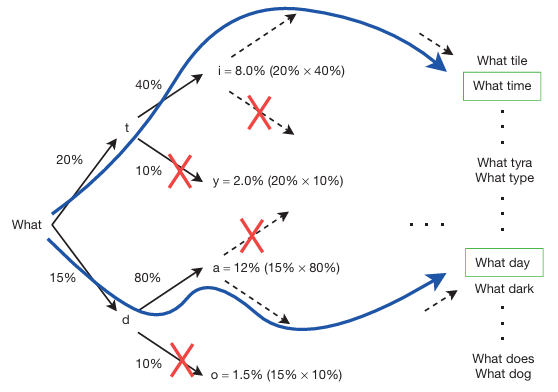 *Exemplo de beam search caractere por caractere, com N=2.*

A sequência de *input* foi "W-h-a-t" seguida por um caractere de espaço. Com esse *input* obtemos um vetor de saída em que a letra "t" é a maior probabilidade e a letra "d" a segunda maior probabilidade. Como N = 2, ignoramos todos os outros candidatos. Realimentamos o primeiro candidato, "t", como *input* da rede e encontramos as duas saídas mais prováveis (i e y). Em outra cópia do modelo, em vez disso, realimentamos o segundo candidato, "d", como *input* e obtemos as duas saídas mais prováveis (a e o). Com isso, temos 4 opções, "What ti", "What ty", "What da" e "What do". Calculando a probabilidade de cada um multiplicando as probabilidades individuais, realizamos o *pruning* dos candidatos, mantendo os 2 candidatos mais prováveis (já que o *N* é 2).

Não há garantia de que a *beam search* encontrará o candidato mais provável no geral, dado que o candidato mais provável pode muito bem ter sido podado no início do processo. Se você está familiarizado com algoritmos de busca, pode notar que é um algoritmo de **busca em largura**, no qual limitamos a largura da busca. A *beam search* também é um exemplo de um **algoritmo guloso (*greedy algorithm*)**.

## **HANDS-ON: PARTE PRÁTICA**

Neste exemplo de programação, criaremos uma *RNN* baseada em *LSTM* que pode ser usada para autocompletar texto. Para isso, primeiro precisamos treinar nossa rede com algum texto existente que possa ser usado como um conjunto de treinamento. Para este exemplo, usarei um livro do **Projeto Gutenberg** - uma coleção de livros que não estão mais protegidos por direitos autorais e estão disponíveis em formato de texto online -, mais especificamente, o *Frankenstein*.

### Código de inicialização

In [6]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
import tensorflow as tf
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 32
BATCH_SIZE = 256
INPUT_FILE_NAME = r'/content/frankenstein.txt'

#Controlar o processo de dividir o arquivo de texto em múltiplas partes de treinamento
WINDOW_LENGTH = 40
WINDOW_STEP = 3

#Controlar o algoritmo de beam search
BEAM_SIZE = 8
NUM_LETTERS = 11
MAX_LENGTH = 50

### Ler o arquivo, processar o texto e preparar os caracteres

In [7]:
#Abrindo o arquivo de texto
file = open(INPUT_FILE_NAME, 'r', encoding='utf-8')
text = file.read()
file.close()

#Transformando o texto em minúsculas, removendo quebras de linha e espaços extras
text = text.lower()
text = text.replace('\n', ' ')
text = text.replace('  ', ' ')

#Realizando o pré-processamento do texto para criar um dicionário de caracteres, um relacionando caracteres e índices e outro vice-versa
unique_chars = list(set(text))
char_to_index = dict((ch, index) for index, ch in enumerate(unique_chars))
index_to_char = dict((index, ch) for index, ch in enumerate(unique_chars))
#Representa a largura do vetor de codificação, ou seja, o número de caracteres únicos
encoding_width = len(char_to_index)

### Preparando o *one-hot encoding* para os dados de treino

In [8]:
#Criando os exemplos de treinamento
fragments = []
targets = []

for i in range(0, len(text) - WINDOW_LENGTH, WINDOW_STEP):
    fragments.append(text[i:i + WINDOW_LENGTH])
    targets.append(text[i + WINDOW_LENGTH])

#Convertendo para *one-hot encoding* os fragmentos e alvos
X = np.zeros((len(fragments), WINDOW_LENGTH, encoding_width))
y = np.zeros((len(fragments), encoding_width))
for i, fragment in enumerate(fragments):
    for j, char in enumerate(fragment):
        X[i, j, char_to_index[char]] = 1
    target_char = targets[i]
    y[i, char_to_index[targets[i]]] = 1

### Criando e treinando o modelo

O modelo consiste em duas camadas *LSTM*, ambas camadas usam um valor de *dropout* de 0,2 nas conexões entre as camadas, bem como nas conexões recorrentes. O *return_sequences=True* é para que a segunda camada veja os valores de saída de todos os passos de tempo da primeira camada. A segunda camada *LSTM* é seguida por uma *fully connected*, com uma camada de saída com múltiplos neurônios usando a função *softmax* para prever as probabilidades das possíveis saídas. Usamos a entropia cruzada categórica como nossa função de perda, que é a função de perda recomendada para classificação multiclasse.

Não dividimos o *dataset* em treino e teste. Em vez disso, usei um parâmetro da função *fit*, o *validation_split*, que faz o *Keras* dividir automaticamente os nossos dados em treino e teste, onde 5% dos dados serão usados para teste. Para o caso de autocompletar texto, poderíamos ter deixado esse parâmetro de fora também e simplesmente treinado usando todos os dados, sem fazer nenhuma validação. Em vez disso, poderíamos ter verificado manualmente a sanidade da saída usando nosso próprio julgamento, já que o resultado "correto" para o autocompletar de texto é um tanto subjetivo. Por fim, o treinamento foi feito por 32 *epochs* e um *batch size* de 256.

In [9]:
model = Sequential()

model.add(Input(shape=(None, encoding_width)))
model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(encoding_width, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()
history = model.fit(X, y, validation_split=0.05, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=2, shuffle=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 128)      │        96,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         7,740 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,092 (922.23 KB)

 Trainable params: 236,092 (922.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
518/518 - 129s - 249ms/step - loss: 2.8146 - val_loss: 2.4498
Epoch 2/32
518/518 - 138s - 266ms/step - loss: 2.3936 - val_loss: 2.2260
Epoch 3/32
518/518 - 142s - 275ms/step - loss: 2.2435 - val_loss: 2.1167
Epoch 4/32
518/518 - 120s - 232ms/step - loss: 2.1548 - val_loss: 2.0366
Epoch 5/32
518/518 - 141s - 273ms/step - loss: 2.0936 - val_loss: 1.9831
Epoch 6/32
518/518 - 119s - 229ms/step - loss: 2.0428 - val_loss: 1.9423
Epoch 7/32
518/518 - 142s - 275ms/step - loss: 2.0044 - val_loss: 1.9031
Epoch 8/32
518/518 - 142s - 274ms/step - loss: 1.9662 - val_loss: 1.8679
Epoch 9/32
518/518 - 142s - 273ms/step - loss: 1.9341 - val_loss: 1.8437
Epoch 10/32
518/518 - 120s - 231ms/step - loss: 1.9081 - val_loss: 1.8168
Epoch 11/32
518/518 - 143s - 276ms/step - loss: 1.8824 - val_loss: 1.7945
Epoch 12/32
518/518 - 141s - 272ms/step - loss: 1.8605 - val_loss: 1.7710
Epoch 13/32
518/518 - 141s - 273ms/step - loss: 1.8434 - val_loss: 1.7543
Epoch 14/32
518/518 - 143s - 276ms/step - loss:

Isso resulta em uma *loss* de treinamento de 1,63 e uma *loss* de teste de 1,56. Provavelmente poderíamos ajustar a rede para produzir valores de perda melhores, mas estamos mais interessados em tentar usar nosso modelo para prever texto. Fazemos isso usando o algoritmo de *beam search* descrito anteriormente.

### **USANDO O MODELO E FAZENDO A BEAM SEARCH PARA AUTOCOMPLETAR TEXTO**

Na implementação, cada *beam* é representado por uma tupla com 3 elementos. O primeiro elemento é o logaritmo da probabilidade acumulada para a sequência atual de caracteres, o uso do logaritmo é para evitar que os números fiquem extremamente pequenos e imprecisos na multiplicação de probabilidades. O segundo elemento é a string de caracteres. O terceiro elemento é uma versão codificada em *one-hot* da string de caracteres.

In [11]:
# Create initial single beam represented by triplet
# (probability , string , one-hot encoded string).
letters = 'the body '
one_hots = []
for i, char in enumerate(letters):
  x = np.zeros(encoding_width)
  x[char_to_index[char]] = 1
  one_hots.append(x)
beams = [(np.log(1.0), letters, one_hots)]

# Predict NUM_LETTERS into the future.
for i in range(NUM_LETTERS):
    minibatch_list = []
# Create minibatch from one-hot encodings, and predict.
    for triple in beams:
        minibatch_list.append(triple[2])
    minibatch = np.array(minibatch_list)
    y_predict = model.predict(minibatch, verbose=0)
    new_beams = []
    for j, softmax_vec in enumerate(y_predict):
        triple = beams[j]
        # Create BEAM_SIZE new beams from each existing beam.
        for k in range(BEAM_SIZE):
            char_index = np.argmax(softmax_vec)
            new_prob = triple[0] + np.log(softmax_vec[char_index])
            new_letters = triple[1] + index_to_char[char_index]
            x = np.zeros(encoding_width)
            x[char_index] = 1
            new_one_hots = triple[2].copy()
            new_one_hots.append(x)
            new_beams.append((new_prob, new_letters, new_one_hots))
            softmax_vec[char_index] = 0
    # Prune tree to only keep BEAM_SIZE most probable beams.
    new_beams.sort(key=lambda tup: tup[0], reverse=True)
    beams = new_beams[0:BEAM_SIZE]
for item in beams:
    print(item[1])

the body which i was
the body which i had
the body which the s
the body which he wa
the body which the w
the body which the m
the body which the c
the body which the d


Nota-se que as frases completadas pelo modelo possuem ortografia correta e têm estruturas gramaticais que parecem razoáveis.

## **RNNs BIDIRECIONAIS**

Quando trabalhamos com sequências de texto, pode ser benéfrico olhar tanto para as palavras futuras quanto para as anteriores. Como exemplo, quando se escreve um parágrafo, é comum escrevermos uma frase, depois outra e voltar para ver como está a conexão dessas duas frases. Outro exemplo, quando estamos conversando com alguém e essa pessoa fala "Eu vi a b", mão não escutamos a última palavra, só ouvi que era uma pequena palavra e começava com 'b'. Provavelmente precisaríamos pedir à pessoa para repetir o que disse, porque não é óbvio qual poderia ser a palavra — poderia ser bola, bula, bala ou qualquer outra palavra que comece com 'b'. Em vez disso, suponha que ouvimos a seguinte frase "Eu vi as n... brancas no céu.", dessa vez não seria necessário pedir que a pessoa repetisse, pois apenas assumiríamos que a palavra é "nuvens". Em outras palavras, olhar para as palavras futuras nos permite prever a palavra ausente, e uma aplicação típica para isso é o reconhecimento de fala.

Uma **RNN bidirecional** é uma arquitetura de rede que tem a capacidade de olhar para as palavras futuras. Uma camada de RNN bidirecional consiste em duas camadas operando em paralelo, mas elas recebem os dados de entrada em direções diferentes. Para que isso funcione, a sequência de entrada completa precisa estar disponível desde o início, portanto, não pode ser usada em um cenário online no qual a sequência é criada dinamicamente. Para simplificar, considere uma camada de RNN regular consistindo em uma única unidade. Se quiséssemos criar uma versão bidirecional desta camada de RNN, adicionaríamos outra unidade. Se, então, quiséssemos alimentar os caracteres h, e, l, l, o para a rede, alimentaríamos h para uma das unidades e o para a outra no primeiro passo de tempo. No passo de tempo 2, alimentaríamos e e l e assim por diante até passar todas as letras para cada unidade. Durante cada passo de tempo, cada uma das duas unidades produziria um valor de saída. No final da sequência, combinaríamos as duas saídas para cada valor de entrada. Ou seja, o valor de saída para o passo de tempo 0 para a primeira unidade e o valor de saída para o passo de tempo 4 para a segunda unidade seriam combinados porque esses passos de tempo representam quando as unidades receberam h como entrada. Existem múltiplas maneiras de combinar a saída de duas unidades, como adição, multiplicação ou média.

### Implementação de uma camada bidirecional usada em uma camada LSTM regular

In [ ]:
from tensorflow.keras.layers import Bidirectional

#Alguma coisa vem aqui .....

model.add(Bidirectional(LSTM(16,activation='relu')))

## **COMBINAÇÕES DISTINTAS DE SEQUÊNCIAS DE *INPUTS* E *OUTPUTS***

O exemplo que fizemos no material sobre *RNN* de previsão de vendas de livros recebia uma sequência de valores como *input* e retornava um único *output*. Esse exemplo, desse material, recebe uma sequência de caracteres como *input* e retorna uma sequência de caracteres como *output*. Outras combinações de *input* e *output* são mostradas na imagem abaixo.

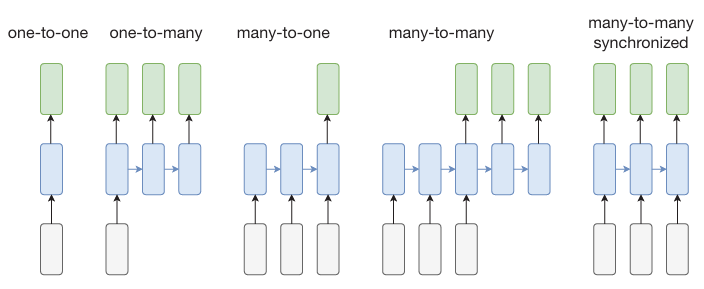

A primeira rede da esquerda, uma rede **um-para-um** não é uma rede recorrente, ela é simplesmente uma rede *feedforward* que recebe um *input* e retorna um *output*. A segunda é uma rede **um-para-muitos**, ela recebe a entrada durante o primeiro passo de tempo e produz múltiplas saídas nos passos de tempo subsequentes (exemplo de uso é a descrição de uma imagem). A terceira é um modelo **muitos-para-um**, que é exatamente o que fizemos no material sobre *RNN* na previsão de vendas dos livros. A quarta é um caso de uma rede **muitos-para-muitos**, que é o que fizemos neste material, o exemplo de autocompletar texto. Por último, mais à direita da imagem, uma rede **muitos-para-muitos sincronizada**, na qual a entrada para cada passo de tempo tem uma saída correspondente (exemplo de uso típico disso é uma rede que classifica cada quadro de um vídeo para determinar se há ou não um gato no quadro).

Esses conceitos não se restringem a redes recorrentes "puras", mas também podem ser aplicadas a arquiteturas híbridas mais complexas.